<a href="https://colab.research.google.com/github/vamsiyadagiri24-dot/Stroke-prediction-agent/blob/main/CKD_Prediction_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Chronic Kidney Disease (CKD) Prediction & Care Agent
### Phase 1: ML Model Training & Comparison
### Phase 2: AI Kidney Care Assistant (Agent)
### Deployment: Streamlit + pyngrok (runs live from Google Colab)

**Dataset:** `Chronic_Kidney_Dsease_data.csv` (54 columns, target = `Diagnosis`, 1 = CKD present, 0 = no CKD)

Run every cell **in order, top to bottom**. Sections are clearly marked.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🔧 Setup — Install Required Packages

In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib streamlit pyngrok
print("✅ All packages installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.6 MB/s eta 0:00:00
✅ All packages installed.


## 📂 Step 1 — Load the Dataset

Upload `Chronic_Kidney_Dsease_data.csv` when prompted (or place it in the Colab file browser first — if it's already there, the upload step is skipped automatically).


In [ ]:
import os
import pandas as pd

DATA_FILE = "Chronic_Kidney_Dsease_data.csv"

if not os.path.exists(DATA_FILE):
    from google.colab import files
    print("Please upload 'Chronic_Kidney_Dsease_data.csv'...")
    uploaded = files.upload()
    DATA_FILE = list(uploaded.keys())[0]

df = pd.read_csv(DATA_FILE)
print("Shape:", df.shape)
df.head()


Shape: (1659, 54)


,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


## 🔍 Step 2 — Exploratory Data Analysis (EDA)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   int64  
 3   Ethnicity                      1659 non-null   int64  
 4   SocioeconomicStatus            1659 non-null   int64  
 5   EducationLevel                 1659 non-null   int64  
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   int64  
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   i

In [ ]:
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("\nTarget distribution (Diagnosis):")
print(df['Diagnosis'].value_counts())
print(df['Diagnosis'].value_counts(normalize=True).round(3))


Missing values per column:
 0 total missing values

Target distribution (Diagnosis):
Diagnosis
1    1524
0     135
Name: count, dtype: int64
Diagnosis
1    0.919
0    0.081
Name: proportion, dtype: float64


/tmp/ipykernel_813/3238137991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='Set2')


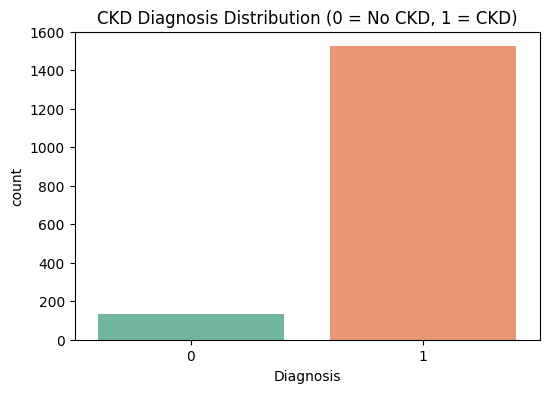

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', data=df, palette='Set2')
plt.title("CKD Diagnosis Distribution (0 = No CKD, 1 = CKD)")
plt.show()


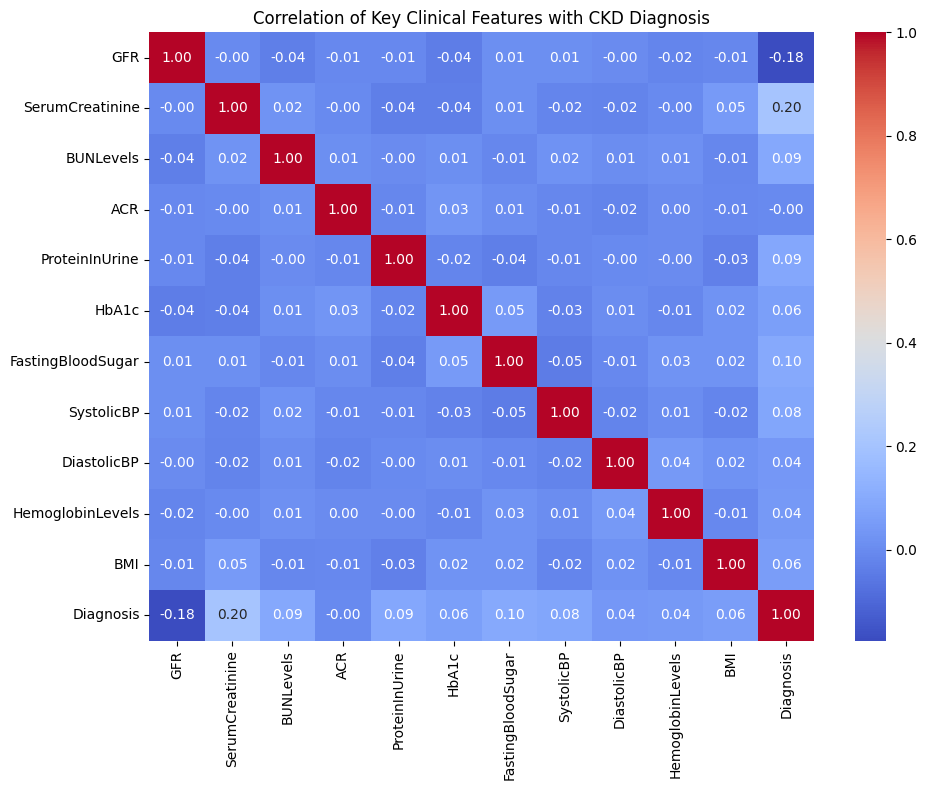

In [ ]:
# Correlation heatmap of key clinical features with the target
key_clinical_features = ['GFR', 'SerumCreatinine', 'BUNLevels', 'ACR', 'ProteinInUrine',
                          'HbA1c', 'FastingBloodSugar', 'SystolicBP', 'DiastolicBP',
                          'HemoglobinLevels', 'BMI', 'Diagnosis']

plt.figure(figsize=(10,8))
sns.heatmap(df[key_clinical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation of Key Clinical Features with CKD Diagnosis")
plt.tight_layout()
plt.show()


## ⚙️ Step 3 — Preprocessing

- Drop identifier columns (`PatientID`, `DoctorInCharge`) — they carry no predictive signal.
- Separate features (`X`) and target (`y` = `Diagnosis`).
- Train/test split (80/20, stratified because the classes are imbalanced: ~92% CKD vs ~8% No-CKD).
- Standardize features for the distance/gradient-based models (SVM, KNN, MLP, Logistic Regression).


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

drop_cols = [c for c in ['PatientID', 'DoctorInCharge'] if c in df.columns]
model_df = df.drop(columns=drop_cols)

X = model_df.drop(columns=['Diagnosis'])
y = model_df['Diagnosis']

FEATURE_NAMES = X.columns.tolist()
print(f"Number of features used: {len(FEATURE_NAMES)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Number of features used: 51
Train shape: (1327, 51)  Test shape: (332, 51)


In [ ]:
# Save feature metadata (used later to auto-build the Streamlit form in Phase 2)
feature_info = {}
for col in FEATURE_NAMES:
    unique_vals = sorted(X[col].unique().tolist())
    is_binary = len(unique_vals) == 2 and set(unique_vals) <= {0, 1}
    feature_info[col] = {
        "is_binary": is_binary,
        "min": float(X[col].min()),
        "max": float(X[col].max()),
        "mean": float(X[col].mean())
    }
print("Sample feature info:", list(feature_info.items())[:3])


Sample feature info: [('Age', {'is_binary': False, 'min': 20.0, 'max': 90.0, 'mean': 54.44122965641953}), ('Gender', {'is_binary': True, 'min': 0.0, 'max': 1.0, 'mean': 0.515370705244123}), ('Ethnicity', {'is_binary': False, 'min': 0.0, 'max': 3.0, 'mean': 0.7130801687763713})]


## 🤖 Step 4 — Train & Compare 6 Machine Learning Models

Logistic Regression, Random Forest, XGBoost, SVM, KNN, and MLP.
Since the dataset is imbalanced (~92% CKD-positive), `class_weight='balanced'` (or `scale_pos_weight` for XGBoost) is used where supported.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', scale_pos_weight=pos_weight, random_state=42),
    "SVM": SVC(probability=True, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3000, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-Score": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })
    trained_models[name] = model
    print(f"✅ Trained: {name}")

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results_df


✅ Trained: Logistic Regression
✅ Trained: Random Forest
✅ Trained: XGBoost
✅ Trained: SVM
✅ Trained: KNN
✅ Trained: MLP


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.743976,0.966102,0.747541,0.842884,0.791864
1,SVM,0.903614,0.938907,0.957377,0.948052,0.785064
2,XGBoost,0.912651,0.945161,0.960656,0.952846,0.774985
3,Random Forest,0.918675,0.918675,1.000000,0.957614,0.765817
4,MLP,0.894578,0.929936,0.957377,0.943457,0.705282
5,KNN,0.918675,0.918675,1.000000,0.957614,0.560838


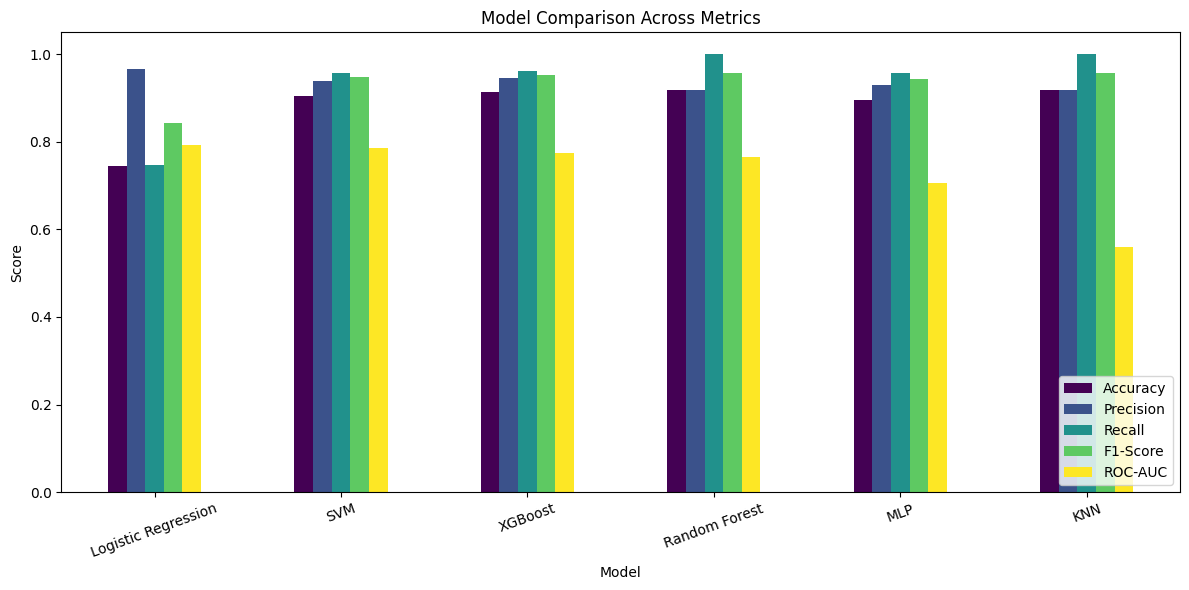

In [ ]:
# Visual comparison of models
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 📊 Step 5 — Confusion Matrices for All Models

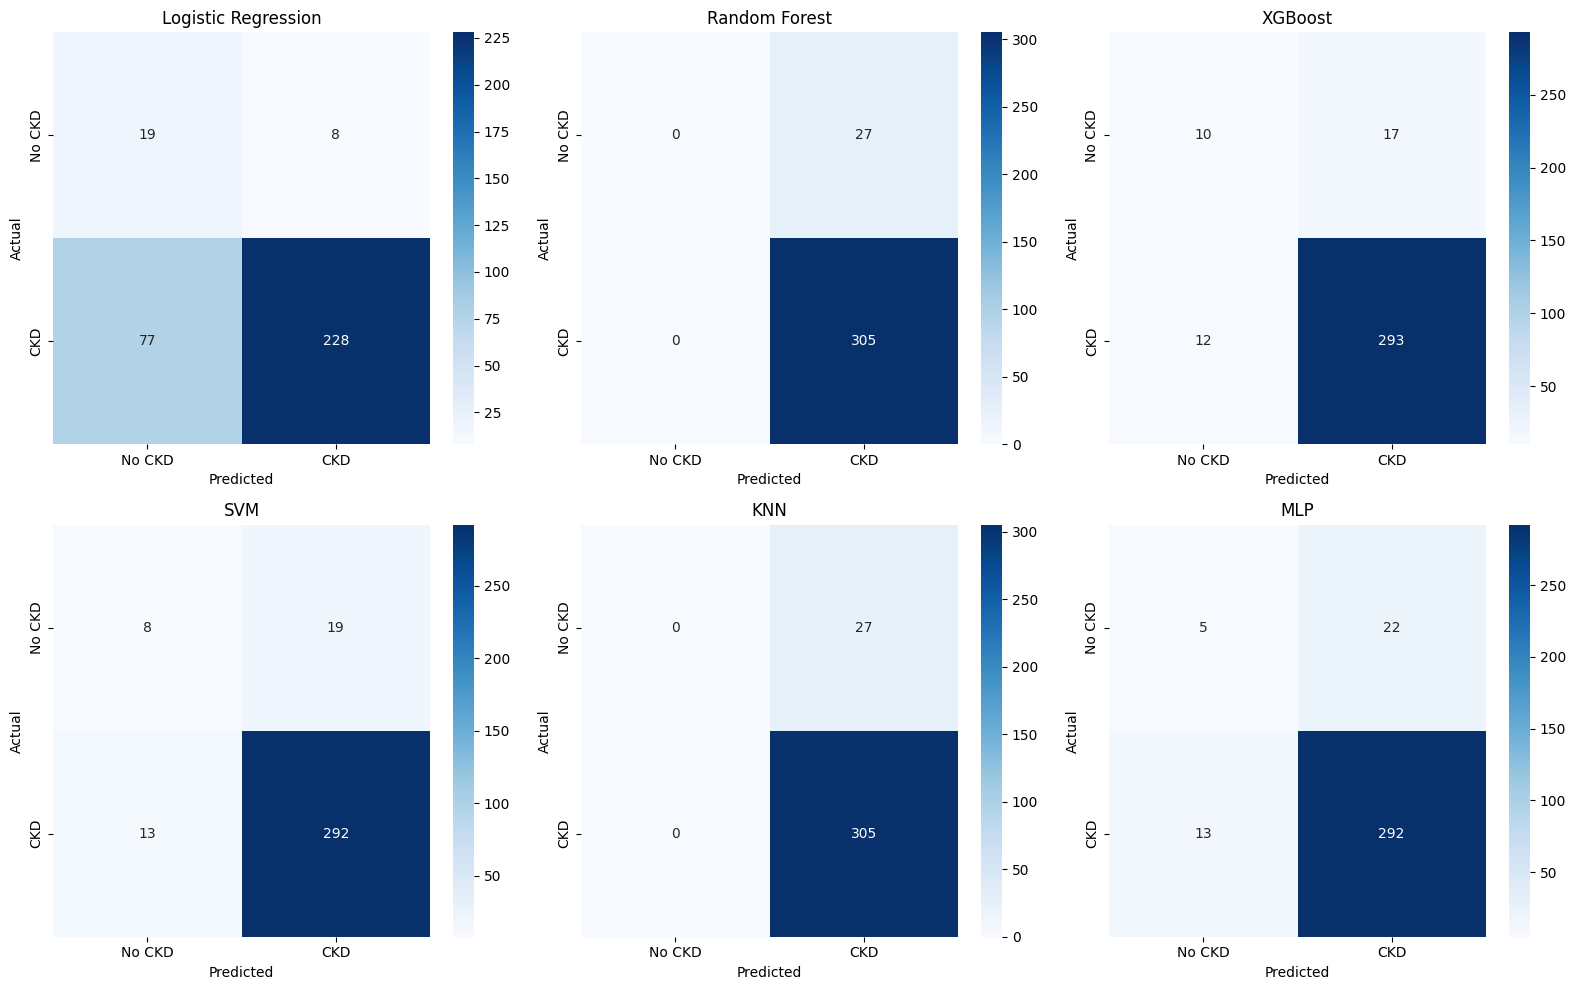

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_models.items()):
    preds = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


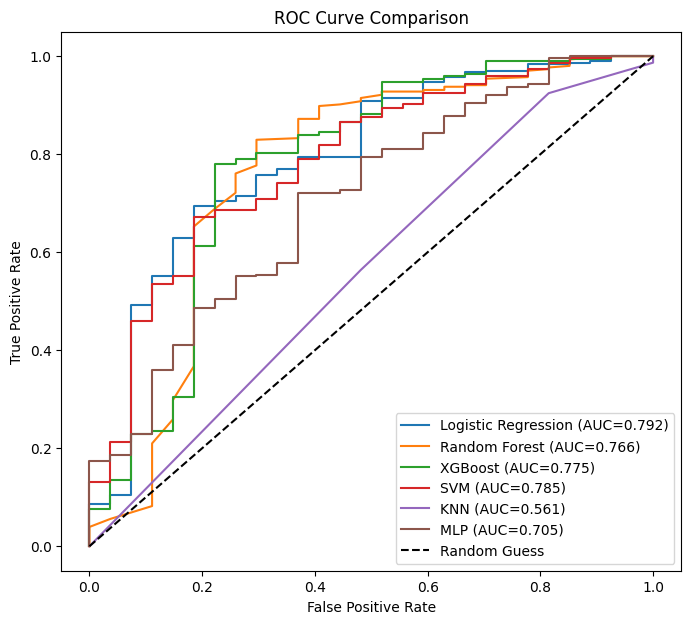

In [ ]:
# ROC curves for all models
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))
for name, model in trained_models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc='lower right')
plt.show()


## 💾 Step 6 — Save the Best Model

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"🏆 Best model: {best_model_name}")
print(results_df.iloc[0])

import joblib
joblib.dump(best_model, "ckd_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FEATURE_NAMES, "feature_names.pkl")
joblib.dump(feature_info, "feature_info.pkl")

print("\n✅ Saved: ckd_model.pkl, scaler.pkl, feature_names.pkl, feature_info.pkl")


🏆 Best model: Logistic Regression
Model        Logistic Regression
Accuracy                0.743976
Precision               0.966102
Recall                  0.747541
F1-Score                0.842884
ROC-AUC                 0.791864
Name: 0, dtype: object

✅ Saved: ckd_model.pkl, scaler.pkl, feature_names.pkl, feature_info.pkl


---
# 🧠 PHASE 2 — AI Kidney Care Agent

An agent class that:
1. Loads the trained model
2. Predicts CKD risk for a patient
3. Generates preventive recommendations based on actual clinical values
4. Stores and retrieves patient assessment history (CSV-based persistence)


In [ ]:
import pandas as pd
import joblib
from datetime import datetime

class CKDCareAgent:
    def __init__(self, model_path="ckd_model.pkl", scaler_path="scaler.pkl",
                 feature_names_path="feature_names.pkl", records_path="patient_records.csv"):
        self.model = joblib.load(model_path)
        self.scaler = joblib.load(scaler_path)
        self.feature_names = joblib.load(feature_names_path)
        self.records_path = records_path

        try:
            self.records = pd.read_csv(records_path)
        except FileNotFoundError:
            self.records = pd.DataFrame(columns=[
                "timestamp", "patient_id", "risk_prediction", "risk_probability", "risk_level"
            ])

    # ---- Prediction ----
    def predict_risk(self, patient_data: dict):
        X = pd.DataFrame([patient_data])[self.feature_names]
        X_scaled = self.scaler.transform(X)
        pred = int(self.model.predict(X_scaled)[0])
        prob = float(self.model.predict_proba(X_scaled)[0][1])

        if prob < 0.3:
            level = "Low"
        elif prob < 0.6:
            level = "Moderate"
        else:
            level = "High"

        return {"prediction": pred, "probability": round(prob, 3), "risk_level": level}

    # ---- Recommendations (rule-based on real clinical markers) ----
    def generate_recommendations(self, patient_data: dict, risk_result: dict):
        tips = []
        g = patient_data.get

        if risk_result["risk_level"] == "High":
            tips.append("⚠️ High predicted CKD risk — please consult a nephrologist for full diagnostic workup.")

        if g("GFR", 90) < 60:
            tips.append(f"GFR is {g('GFR'):.1f} mL/min (reduced kidney function) — avoid NSAIDs and nephrotoxic drugs, and get kidney function monitored regularly.")
        if g("SerumCreatinine", 1) > 1.3:
            tips.append("Elevated serum creatinine — reduce high-protein diets and stay well hydrated.")
        if g("BUNLevels", 15) > 20:
            tips.append("Elevated BUN — moderate protein intake and monitor kidney function.")
        if g("ACR", 10) > 30:
            tips.append("Elevated urine albumin-to-creatinine ratio — a key marker of kidney damage; needs medical follow-up.")
        if g("ProteinInUrine", 0) > 1:
            tips.append("Protein detected in urine — reduce sodium intake and consult a doctor about ACE inhibitors/ARBs.")
        if g("HbA1c", 5) > 6.5 or g("FastingBloodSugar", 90) > 126:
            tips.append("Blood sugar markers indicate diabetes risk — diabetes is a leading cause of CKD; manage blood sugar closely.")
        if g("SystolicBP", 120) > 140 or g("DiastolicBP", 80) > 90:
            tips.append("Blood pressure is elevated — hypertension accelerates kidney damage; reduce salt intake and monitor BP regularly.")
        if g("BMI", 22) > 30:
            tips.append("BMI indicates obesity — weight management reduces strain on kidney function.")
        if g("Smoking", 0) == 1:
            tips.append("Smoking accelerates kidney function decline — consider a cessation program.")
        if g("HemoglobinLevels", 13) < 11:
            tips.append("Low hemoglobin (anemia) — common in CKD; discuss iron/EPO evaluation with your doctor.")
        if g("PhysicalActivity", 5) < 2:
            tips.append("Low physical activity — regular moderate exercise supports cardiovascular and kidney health.")
        if g("MedicationAdherence", 8) < 5:
            tips.append("Medication adherence appears low — consistent use of prescribed medication is critical for slowing CKD progression.")

        if not tips:
            tips.append("Your key clinical markers are within a generally healthy range. Keep up regular checkups.")

        tips.append("General prevention: stay hydrated, maintain a low-sodium balanced diet, manage blood pressure/blood sugar, avoid unnecessary NSAIDs, and get annual kidney function screening.")
        return tips

    # ---- Persistence ----
    def save_record(self, patient_id, patient_data, risk_result):
        row = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "patient_id": patient_id,
            "risk_prediction": risk_result["prediction"],
            "risk_probability": risk_result["probability"],
            "risk_level": risk_result["risk_level"]
        }
        self.records = pd.concat([self.records, pd.DataFrame([row])], ignore_index=True)
        self.records.to_csv(self.records_path, index=False)

    def get_patient_history(self, patient_id):
        return self.records[self.records["patient_id"] == patient_id]

    # ---- Full pipeline ----
    def assess_patient(self, patient_id, patient_data):
        risk_result = self.predict_risk(patient_data)
        recommendations = self.generate_recommendations(patient_data, risk_result)
        self.save_record(patient_id, patient_data, risk_result)
        return {
            "patient_id": patient_id,
            "risk_result": risk_result,
            "recommendations": recommendations
        }

print("✅ CKDCareAgent class defined.")


✅ CKDCareAgent class defined.


In [ ]:
# Quick test of the agent using the mean values of the dataset as a sample patient
agent = CKDCareAgent()

sample_patient = X_test.iloc[0].to_dict()
report = agent.assess_patient("P001", sample_patient)

print("Risk result:", report["risk_result"])
print("\nRecommendations:")
for tip in report["recommendations"]:
    print("-", tip)


Risk result: {'prediction': 1, 'probability': 0.975, 'risk_level': 'High'}

Recommendations:
- ⚠️ High predicted CKD risk — please consult a nephrologist for full diagnostic workup.
- GFR is 59.3 mL/min (reduced kidney function) — avoid NSAIDs and nephrotoxic drugs, and get kidney function monitored regularly.
- Elevated serum creatinine — reduce high-protein diets and stay well hydrated.
- Elevated BUN — moderate protein intake and monitor kidney function.
- Elevated urine albumin-to-creatinine ratio — a key marker of kidney damage; needs medical follow-up.
- Protein detected in urine — reduce sodium intake and consult a doctor about ACE inhibitors/ARBs.
- Blood sugar markers indicate diabetes risk — diabetes is a leading cause of CKD; manage blood sugar closely.
- Blood pressure is elevated — hypertension accelerates kidney damage; reduce salt intake and monitor BP regularly.
- BMI indicates obesity — weight management reduces strain on kidney function.
- Low physical activity — regu

/tmp/ipykernel_813/2155601369.py:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.records = pd.concat([self.records, pd.DataFrame([row])], ignore_index=True)


---
# 🚀 DEPLOYMENT — Streamlit App via pyngrok (live from Colab)

This writes a full Streamlit app (`app.py`) that combines Phase 1 (model) + Phase 2 (agent),
then launches it and exposes a **public URL** using pyngrok, so you can open and share it directly.

### You need a free ngrok authtoken:
1. Sign up at https://dashboard.ngrok.com/signup (free)
2. Copy your token from https://dashboard.ngrok.com/get-started/your-authtoken
3. Paste it into the `NGROK_AUTH_TOKEN` variable in the cell below.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
from datetime import datetime

st.set_page_config(page_title="CKD Care Assistant", page_icon="🩺", layout="wide")

@st.cache_resource
def load_artifacts():
    model = joblib.load("ckd_model.pkl")
    scaler = joblib.load("scaler.pkl")
    feature_names = joblib.load("feature_names.pkl")
    feature_info = joblib.load("feature_info.pkl")
    return model, scaler, feature_names, feature_info

model, scaler, FEATURE_NAMES, FEATURE_INFO = load_artifacts()

# ---------- Prediction ----------
def predict_risk(data: dict):
    X = pd.DataFrame([data])[FEATURE_NAMES]
    X_scaled = scaler.transform(X)
    pred = int(model.predict(X_scaled)[0])
    prob = float(model.predict_proba(X_scaled)[0][1])
    level = "Low" if prob < 0.3 else "Moderate" if prob < 0.6 else "High"
    return pred, prob, level

# ---------- Recommendations ----------
def generate_recommendations(data: dict, level: str):
    tips = []
    g = data.get

    if level == "High":
        tips.append("⚠️ High predicted CKD risk — please consult a nephrologist for a full diagnostic workup.")
    if g("GFR", 90) < 60:
        tips.append(f"GFR is {g('GFR'):.1f} mL/min (reduced kidney function) — avoid NSAIDs/nephrotoxic drugs and get monitored regularly.")
    if g("SerumCreatinine", 1) > 1.3:
        tips.append("Elevated serum creatinine — reduce high-protein diets and stay well hydrated.")
    if g("BUNLevels", 15) > 20:
        tips.append("Elevated BUN — moderate protein intake and monitor kidney function.")
    if g("ACR", 10) > 30:
        tips.append("Elevated urine albumin-to-creatinine ratio — a key kidney-damage marker; needs medical follow-up.")
    if g("ProteinInUrine", 0) > 1:
        tips.append("Protein detected in urine — reduce sodium intake and ask your doctor about ACE inhibitors/ARBs.")
    if g("HbA1c", 5) > 6.5 or g("FastingBloodSugar", 90) > 126:
        tips.append("Blood sugar markers indicate diabetes risk — diabetes is a leading cause of CKD; manage blood sugar closely.")
    if g("SystolicBP", 120) > 140 or g("DiastolicBP", 80) > 90:
        tips.append("Blood pressure is elevated — hypertension accelerates kidney damage; reduce salt intake.")
    if g("BMI", 22) > 30:
        tips.append("BMI indicates obesity — weight management reduces strain on kidney function.")
    if g("Smoking", 0) == 1:
        tips.append("Smoking accelerates kidney function decline — consider a cessation program.")
    if g("HemoglobinLevels", 13) < 11:
        tips.append("Low hemoglobin (anemia) — common in CKD; discuss iron/EPO evaluation with your doctor.")
    if g("PhysicalActivity", 5) < 2:
        tips.append("Low physical activity — regular moderate exercise supports kidney health.")
    if g("MedicationAdherence", 8) < 5:
        tips.append("Medication adherence appears low — consistent medication use is critical for slowing CKD progression.")

    if not tips:
        tips.append("Key clinical markers are within a generally healthy range. Keep up regular checkups.")
    tips.append("General prevention: stay hydrated, maintain a low-sodium diet, manage blood pressure/blood sugar, avoid unnecessary NSAIDs, and get annual kidney screening.")
    return tips

# ---------- UI ----------
st.title("🩺 Chronic Kidney Disease Care Assistant")
st.caption("Enter patient clinical data to assess CKD risk and receive preventive recommendations.")

if "history" not in st.session_state:
    st.session_state.history = []

# Group features: binary (Yes/No dropdowns) vs continuous (number inputs)
binary_features = [f for f in FEATURE_NAMES if FEATURE_INFO[f]["is_binary"]]
continuous_features = [f for f in FEATURE_NAMES if not FEATURE_INFO[f]["is_binary"]]

with st.form("patient_form"):
    patient_id = st.text_input("Patient ID", value="P001")

    st.subheader("Clinical & Lab Measurements")
    cont_cols = st.columns(3)
    cont_values = {}
    for i, feat in enumerate(continuous_features):
        info = FEATURE_INFO[feat]
        default = round(info["mean"], 2)
        with cont_cols[i % 3]:
            cont_values[feat] = st.number_input(
                feat, min_value=float(info["min"]), max_value=float(info["max"]),
                value=float(default)
            )

    st.subheader("Lifestyle, History & Risk Factors (Yes/No)")
    bin_cols = st.columns(4)
    bin_values = {}
    for i, feat in enumerate(binary_features):
        with bin_cols[i % 4]:
            choice = st.selectbox(feat, options=["No", "Yes"])
            bin_values[feat] = 1 if choice == "Yes" else 0

    submitted = st.form_submit_button("🔍 Assess CKD Risk")

if submitted:
    patient_data = {**cont_values, **bin_values}
    pred, prob, level = predict_risk(patient_data)

    color = {"Low": "green", "Moderate": "orange", "High": "red"}[level]
    st.markdown(f"## Risk Level: :{color}[{level}]  (probability: {prob:.1%})")

    st.subheader("📋 Preventive Recommendations")
    for tip in generate_recommendations(patient_data, level):
        st.write("•", tip)

    st.session_state.history.append({
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "patient_id": patient_id,
        "risk_level": level,
        "probability": round(prob, 3)
    })

if st.session_state.history:
    st.subheader("🗂️ Assessment History (this session)")
    st.dataframe(pd.DataFrame(st.session_state.history), use_container_width=True)


Writing app.py


In [ ]:
from pyngrok import ngrok
ngrok.kill()

In [ ]:
# ---- Launch Streamlit + create a public link with pyngrok ----
from pyngrok import ngrok
import subprocess, time

# 🔑 PASTE YOUR NGROK AUTHTOKEN HERE (https://dashboard.ngrok.com/get-started/your-authtoken)
NGROK_AUTH_TOKEN = "3GX2pLoue3QesnEQj8Hq3iEZiLJ_3hAoxQhpcMPGmbggdFav8"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Kill any previously running tunnels/streamlit processes (safe to run every time)
ngrok.kill()
!pkill -f streamlit

# Launch the Streamlit app in the background
streamlit_process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"]
)
time.sleep(6)

# Open a public tunnel to port 8501
public_url = ngrok.connect(8501, "http")
print("✅ Your Streamlit CKD Care Assistant is live at:")
print(public_url)


✅ Your Streamlit CKD Care Assistant is live at:
NgrokTunnel: "https://manhunt-undrilled-reference.ngrok-free.dev" -> "http://localhost:8501"


### Notes
- The `ngrok` link stays live only while this Colab cell/runtime is running. Closing the notebook or the runtime disconnects it.
- Free ngrok URLs change every time you re-run the tunnel — copy the new link each session.
- To stop the app: run `ngrok.kill()` and `!pkill -f streamlit` in a new cell.
- For a **permanent** link that doesn't depend on Colab staying open, push `app.py`, `ckd_model.pkl`, `scaler.pkl`, `feature_names.pkl`, `feature_info.pkl`, and a `requirements.txt` to a GitHub repo and deploy for free on [share.streamlit.io](https://share.streamlit.io).


In [ ]:
# Optional: stop the app and tunnel when you're done
# ngrok.kill()
# !pkill -f streamlit
# print("Stopped.")
